In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# --------------------------------------------------
# 1. Load cleaned data
# --------------------------------------------------

df = pd.read_csv("../data/processed/churn_cleaned.csv")

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# --------------------------------------------------
# 2. Standardize column names
# --------------------------------------------------

df.columns = df.columns.str.strip().str.lower()

print("\nColumns after standardization:")
print(df.columns.tolist())


# --------------------------------------------------
# 3. Make sure target exists
# --------------------------------------------------

print("\nChurn values:")
print(df["churn"].value_counts(dropna=False))


# --------------------------------------------------
# 4. Convert target to 0/1
# --------------------------------------------------

df["churn"] = df["churn"].map({
    "Yes": 1,
    "No": 0,
    "yes": 1,
    "no": 0,
    1: 1,
    0: 0
})

print("\nEncoded churn:")
print(df["churn"].value_counts(dropna=False))


# --------------------------------------------------
# 5. Separate features and target
# --------------------------------------------------

X = df.drop(columns=["churn"])
y = df["churn"]


# --------------------------------------------------
# 6. Remove customer ID
# --------------------------------------------------

if "customerid" in X.columns:
    X = X.drop(columns=["customerid"])

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# --------------------------------------------------
# 7. Identify numerical and categorical columns
# --------------------------------------------------

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


# --------------------------------------------------
# 8. Preprocessing pipelines
# --------------------------------------------------

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# --------------------------------------------------
# 9. Combine preprocessing
# --------------------------------------------------

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# --------------------------------------------------
# 10. Train-test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 11. Fit preprocessing ONLY on training data
# --------------------------------------------------

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


# --------------------------------------------------
# 12. Convert to DataFrames
# --------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_test = pd.DataFrame(
    X_test,
    columns=feature_names
)


# --------------------------------------------------
# 13. Final verification
# --------------------------------------------------

print("\n========== FINAL DATA ==========")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_test :", y_test.isna().sum())

print("\nTarget distribution:")
print(y_train.value_counts())
print(y_test.value_counts())

print("\nFeature data types:")
print(X_train.dtypes.value_counts())

Shape: (7043, 21)
Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Columns after standardization:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']

Churn values:
churn
No     5174
Yes    1869
Name: count, dtype: int64

Encoded churn:
churn
0    5174
1    1869
Name: count, dtype: int64

X shape: (7043, 19)
y shape: (7043,)

Numerical features:
['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']

Categorical features:
['gender',

C:\Users\Isha\AppData\Local\Temp\ipykernel_8624\4261428196.py:83: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [14]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.604
ROC-AUC  : 0.8421


Confusion Matrix:
[[926 109]
 [165 209]]


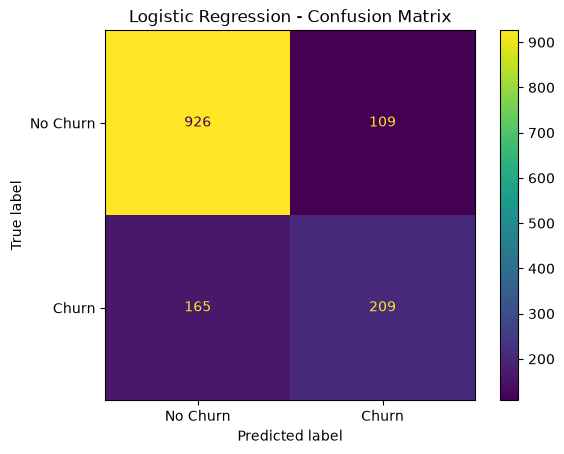

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_pred = random_forest.predict(X_test)
rf_prob = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1 Score :", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob), 4))

Random Forest Results
---------------------
Accuracy : 0.7573
Precision: 0.5295
Recall   : 0.7674
F1 Score : 0.6266
ROC-AUC  : 0.8393


Random Forest Confusion Matrix:
[[780 255]
 [ 87 287]]


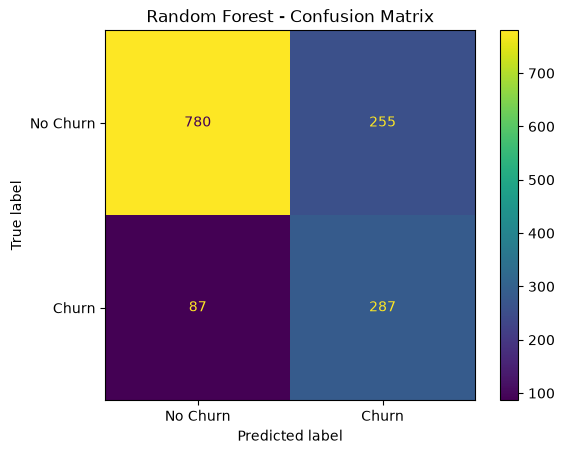

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_forest.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

# Display top 15
print(feature_importance.head(15))

                                feature  importance
1                           num__tenure    0.124898
36         cat__contract_Month-to-month    0.123096
3                     num__totalcharges    0.104198
2                   num__monthlycharges    0.074003
38               cat__contract_Two year    0.062962
18               cat__onlinesecurity_No    0.054795
16     cat__internetservice_Fiber optic    0.049064
27                  cat__techsupport_No    0.045651
43  cat__paymentmethod_Electronic check    0.036951
37               cat__contract_One year    0.020113
21                 cat__onlinebackup_No    0.017708
20              cat__onlinesecurity_Yes    0.015854
15             cat__internetservice_DSL    0.015425
39             cat__paperlessbilling_No    0.012512
29                 cat__techsupport_Yes    0.011911


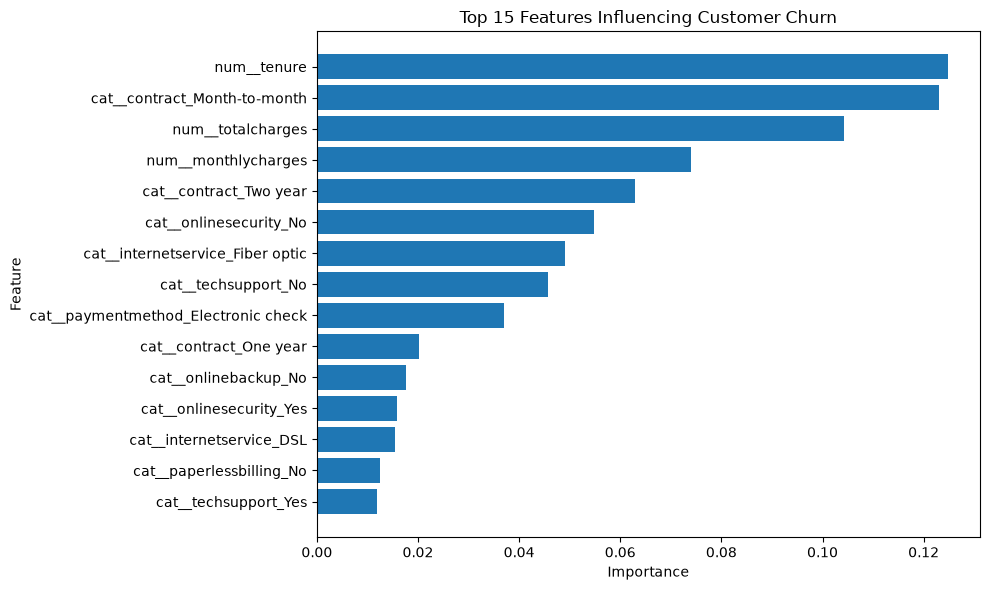

In [21]:
top_features = feature_importance.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Customer Churn")

plt.tight_layout()
plt.show()

In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,Random Forest,0.7573,0.5295,0.7674,0.6266,0.8393


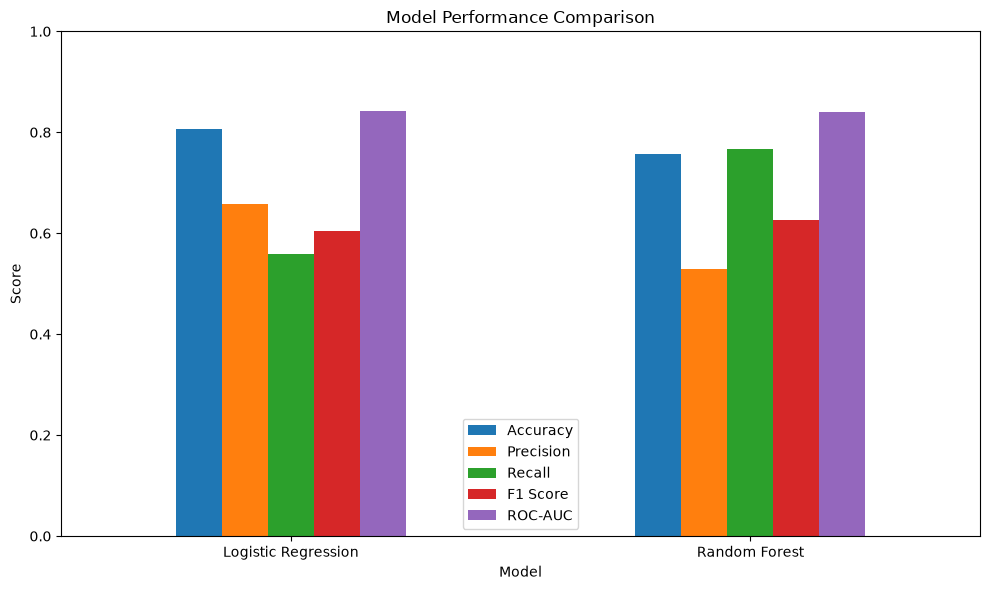

In [23]:
comparison.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

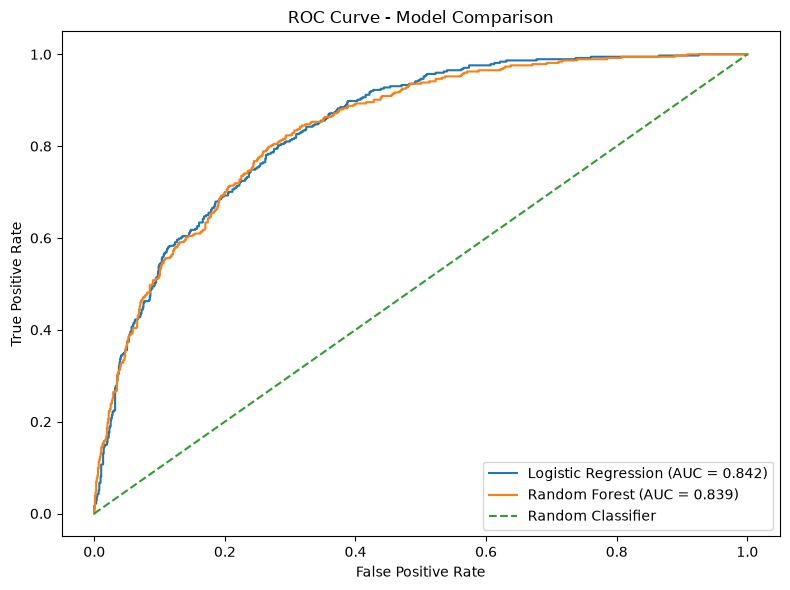

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
lr_auc = auc(lr_fpr, lr_tpr)

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = auc(rf_fpr, rf_tpr)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")

plt.legend()
plt.tight_layout()
plt.show()

In [25]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

joblib.dump(
    random_forest,
    "../models/random_forest.pkl"
)

print("Models saved successfully!")

Models saved successfully!
